https://www.youtube.com/watch?v=mCL2xLBDw8M

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

In [2]:
df = pd.read_csv('titanic_toy.csv')
df.head()

,Age,Fare,Family,Survived
0,22.0,7.2500,1,0
1,38.0,71.2833,1,1
2,26.0,7.9250,0,1
3,35.0,53.1000,1,1
4,35.0,8.0500,0,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Age       714 non-null    float64
 1   Fare      846 non-null    float64
 2   Family    891 non-null    int64  
 3   Survived  891 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 28.0 KB


# Separate Features and Target

Split the dataset into input features (`X`) and the target variable (`y`).

In [4]:
X = df.drop(columns=['Survived'])    # all coulmns except the output column which is survived
y = df['Survived']    # output column which is survived

# Split the Dataset

Divide the dataset into training and testing sets.

In [7]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)   # 80% data for training and 20% for testing, random state ko koi b value deny se jb b code run hoga testing data me whi 20% datapoints ayan gay

X_train.shape, X_test.shape


((712, 3), (179, 3))

In [8]:
X_train.isnull().mean()

,0
Age,0.207865
Fare,0.050562
Family,0.000000


# Calculate Mean and Median

Compute the mean and median values of the numerical columns that contain missing values.

In [9]:
mean_age = X_train['Age'].mean()
median_age = X_train['Age'].median()

mean_fare = X_train['Fare'].mean()
median_fare = X_train['Fare'].median()

# Perform Mean and Median Imputation Using Pandas

Fill the missing values manually using Pandas. New columns are created so the original data remains unchanged.

In [10]:
X_train['Age_median'] = X_train['Age'].fillna(median_age)
X_train['Age_mean'] = X_train['Age'].fillna(mean_age)

X_train['Fare_median'] = X_train['Fare'].fillna(median_fare)
X_train['Fare_mean'] = X_train['Fare'].fillna(mean_fare)

X_train.sample(5)

,Age,Fare,Family,Age_median,Age_mean,Fare_median,Fare_mean
71,16.0,46.900,7,16.0,16.0,46.900,46.900
694,60.0,26.550,0,60.0,60.0,26.550,26.550
724,27.0,53.100,1,27.0,27.0,53.100,53.100
842,30.0,31.000,0,30.0,30.0,31.000,31.000
807,18.0,7.775,0,18.0,18.0,7.775,7.775


# Compare Distribution of Age

Plot the original, median-imputed, and mean-imputed Age distributions to observe how imputation changes the data distribution.

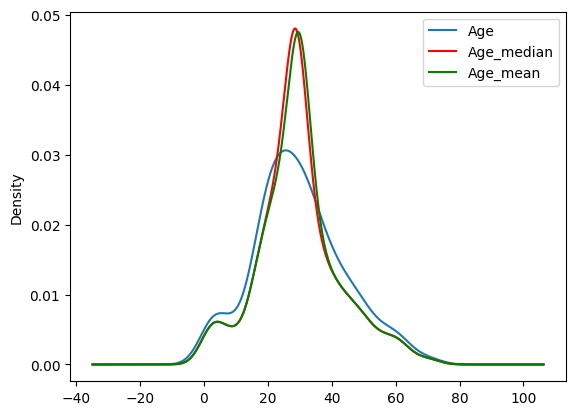

In [11]:
fig = plt.figure()
ax = fig.add_subplot(111)

# original variable distribution
X_train['Age'].plot(kind='kde', ax=ax)

# variable imputed with the median
X_train['Age_median'].plot(kind='kde', ax=ax, color='red')

# variable imputed with the mean
X_train['Age_mean'].plot(kind='kde', ax=ax, color='green')

# add legends
lines, labels = ax.get_legend_handles_labels()
ax.legend(lines, labels, loc='best')

# Note:
 Check for fare by using same method

# Check Covariance

Covariance shows how numerical features vary together and whether changes in one feature are associated with changes in another.
# Covariance

**Definition:**

Covariance measures how **two variables change together**. It tells us whether they move in the same direction or in opposite directions.

### Interpretation

| Covariance Value | Meaning |
|------------------|---------|
| Positive (+) | Both variables increase or decrease together. |
| Negative (-) | One variable increases while the other decreases. |
| Zero (0) | No linear relationship between the variables. |

### Example

If the number of **hours studied** increases and **marks** also increase, the covariance is **positive**.

If **temperature** increases and **jacket sales** decrease, the covariance is **negative**.

### Limitation

Covariance does **not have a fixed range**, so it is difficult to determine how strong the relationship is.

---

# Correlation

**Definition:**

Correlation measures both the **direction** and the **strength** of the relationship between two variables.

### Range

Correlation values always lie between:

```text
-1 to +1
```

### Interpretation

| Correlation Value | Meaning |
|-------------------|---------|
| +1 | Perfect positive relationship |
| +0.8 | Strong positive relationship |
| +0.5 | Moderate positive relationship |
| 0 | No linear relationship |
| -0.5 | Moderate negative relationship |
| -0.8 | Strong negative relationship |
| -1 | Perfect negative relationship |

### Example

If students who study more consistently obtain higher marks, the correlation between **Hours Studied** and **Marks** will be close to **+1**.

---

# Difference Between Covariance and Correlation

| Covariance | Correlation |
|------------|-------------|
| Shows the direction of the relationship. | Shows both the direction and the strength of the relationship. |
| Has no fixed range. | Always ranges from **-1 to +1**. |
| Depends on the units of measurement. | Does not depend on the units of measurement. |
| Harder to interpret. | Easier to interpret and compare. |

---

# In Pandas

### Covariance


In [12]:
X_train.cov()

,Age,Fare,Family,Age_median,Age_mean,Fare_median,Fare_mean
Age,204.349513,70.719262,-6.498901,204.349513,204.349513,64.858859,66.665205
Fare,70.719262,2448.197914,17.258917,57.957599,55.603719,2448.197914,2448.197914
Family,-6.498901,17.258917,2.735252,-5.112563,-5.146106,16.476305,16.385048
Age_median,204.349513,57.957599,-5.112563,161.989566,161.812625,53.553455,55.023037
Age_mean,204.349513,55.603719,-5.146106,161.812625,161.812625,51.358000,52.788341
Fare_median,64.858859,2448.197914,16.476305,53.553455,51.358000,2340.091022,2324.238526
Fare_mean,66.665205,2448.197914,16.385048,55.023037,52.788341,2324.238526,2324.238526


# Check Correlation

Calculate the correlation between numerical features to understand the strength and direction of their relationships.

In [13]:
X_train.corr()

,Age,Fare,Family,Age_median,Age_mean,Fare_median,Fare_mean
Age,1.000000,0.092644,-0.299113,1.000000,1.000000,0.087356,0.090156
Fare,0.092644,1.000000,0.208268,0.091757,0.088069,1.000000,1.000000
Family,-0.299113,0.208268,1.000000,-0.242883,-0.244610,0.205942,0.205499
Age_median,1.000000,0.091757,-0.242883,1.000000,0.999454,0.086982,0.089673
Age_mean,1.000000,0.088069,-0.244610,0.999454,1.000000,0.083461,0.086078
Fare_median,0.087356,1.000000,0.205942,0.086982,0.083461,1.000000,0.996607
Fare_mean,0.090156,1.000000,0.205499,0.089673,0.086078,0.996607,1.000000


# Detect Outliers in Age

Use boxplots to compare the original and imputed Age columns and observe whether new outliers appear after imputation.

<Axes: >

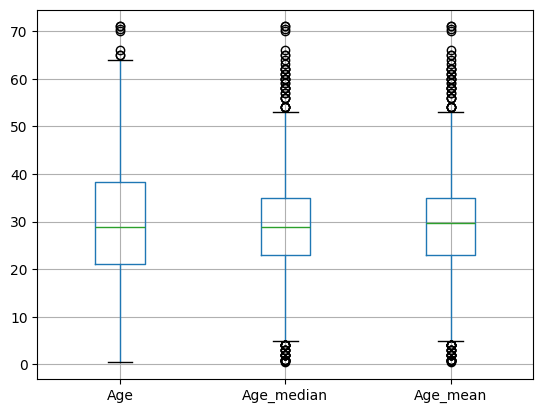

In [14]:
X_train[['Age', 'Age_median', 'Age_mean']].boxplot()

# Same for fare

# Apply Mean and Median Imputation Using Scikit-learn

Split the dataset again before applying Scikit-learn transformers.

In [15]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [16]:
imputer1 = SimpleImputer(strategy='median')
imputer2 = SimpleImputer(strategy='mean')

# Create a Column Transformer

Apply median imputation to the Age column and mean imputation to the Fare column while keeping the remaining columns unchanged.

In [17]:
trf = ColumnTransformer([
    ('imputer1',imputer1,['Age']),
    ('imputer2',imputer2,['Fare'])
],remainder='passthrough')

# Train the Transformer

Fit the transformer on the training data so it learns the median of Age and the mean of Fare.

In [18]:
trf.fit(X_train)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


ColumnTransformer(remainder='passthrough',
                  transformers=[('imputer1', SimpleImputer(strategy='median'),
                                 ['Age']),
                                ('imputer2', SimpleImputer(), ['Fare'])])

# Check Learned Median Value

Display the median value calculated for the Age column.

In [19]:
trf.named_transformers_['imputer1'].statistics_

array([28.75])

# Check Learned Mean Value

Display the mean value calculated for the Fare column.

In [20]:
trf.named_transformers_['imputer2'].statistics_

array([32.61759689])

# Transform the Training and Testing Data

Replace missing values in both the training and testing datasets using the statistics learned from the training data.

In [21]:
X_train = trf.transform(X_train)
X_test = trf.transform(X_test)

X_train

array([[ 40.    ,  27.7208,   0.    ],
       [  4.    ,  16.7   ,   2.    ],
       [ 47.    ,   9.    ,   0.    ],
       ...,
       [ 71.    ,  49.5042,   0.    ],
       [ 28.75  , 221.7792,   0.    ],
       [ 28.75  ,  25.925 ,   0.    ]])